# Global-to-local validation of multiscale HEALPix divergence and curl

This notebook uses ERA5 10-m eastward/northward wind (`u`, `v`) to validate `HealPixDivCurl` and `HealPixMultiScaleDivCurl`. It first computes a physical full-sphere spectral reference with ALM, then masks the same wind on a coastal NESTED HEALPix domain and checks whether the local multiscale diagnostic preserves the meaningful divergence/curl structures. Input channel zero is eastward velocity `u`; channel one is northward velocity `v`.

In [1]:
import healpix_geo
import matplotlib.pyplot as plt
import numpy as np
import torch

from healpix_analyse import (
    HealPixDecomp,
    HealPixDivCurl,
    HealPixMultiScaleDivCurl,
)

torch.manual_seed(3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
RADIUS_M = 6_371_008.8
print("device:", device)

device: cuda


## Coastal masked domain

We use a coastal HEALPix footprint as an irregular missing-data mask. The mask is not a physical wind boundary condition: ERA5 wind remains a global field and does not follow the coastline. This makes the experiment a controlled test of local derivatives with incomplete stencils, rather than a test of coastal wind dynamics.

In [2]:
import fsspec
import xarray as xr
fs = fsspec.filesystem("http")
ds=xr.open_zarr('https://data-taos.ifremer.fr/EGU25_CFOSAT/MARS_SST_EX.zarr')
ds

<xarray.Dataset> Size: 90MB
Dimensions:    (time: 24, depth: 8, latitude: 180, longitude: 324)
Coordinates:
  * time       (time) datetime64[ns] 192B 2025-03-20 ... 2025-03-20T23:00:00
  * depth      (depth) float32 32B 0.494 1.541 2.646 3.819 ... 6.441 7.93 9.573
  * latitude   (latitude) float32 720B 46.03 46.05 46.08 ... 50.94 50.97 51.0
  * longitude  (longitude) float32 1kB -7.999 -7.971 -7.944 ... 0.9456 0.9733
Data variables:
    thetao     (time, depth, latitude, longitude) float64 90MB dask.array<chunksize=(1, 1, 180, 324), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.8
    comment:      
    contact:      https://marine.copernicus.eu/contact
    institution:  NOW Systems (Spain)
    references:   http://marine.copernicus.eu/
    source:       NEMO3.6
    title:        Ocean 3D hourly mean fields for the Iberia-Biscay-Ireland (...

In [3]:
from healpix_resample import PSFResampler

# Define the HEALPix resolution
LEVEL = 11
data = ds.thetao.compute().values[12,0,:,:].astype('float64')
lon = np.tile(ds.longitude.compute().values,data.shape[0]).astype('float64')
lat = np.repeat(ds.latitude.compute().values,data.shape[1]).astype('float64')
data =data.flatten()

lon=lon[np.isfinite(data)]
lat=lat[np.isfinite(data)]
data=data[np.isfinite(data)]

resampler = PSFResampler(
    lon_deg=lon, 
    lat_deg=lat,
    level=LEVEL, 
    threshold=0.1, 
    verbose=True,
    device=device,
)

res = resampler.resample(data, lam=0.01, max_iter=30)

[PSFResampler] area not provided: auto-estimated from shared-latitude-ring grid structure.
Itt 0 : 6.088e+09
Itt 4 : 4.18e+07
Itt 8 : 6.128e+07
Itt 12 : 2.068e+06
Itt 16 : 3.381e+05
Itt 20 : 1.005e+05
Itt 24 : 1.059e+04
Itt 28 : 1929
Final Itt 29 : 1296


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

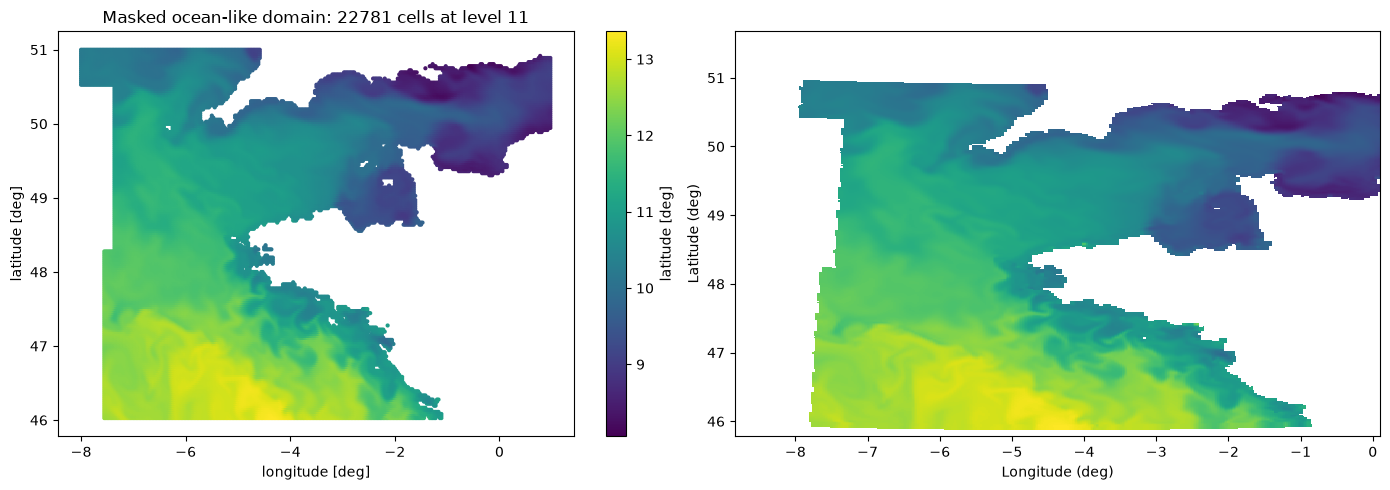

In [4]:
from foscat.Plot import lgnomproject

cell_ids=res.cell_ids
velocity = res.cell_data

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
plt.scatter(lon, lat, c=data, s=4, cmap="viridis")
plt.xlabel("longitude [deg]")
plt.ylabel("latitude [deg]")
plt.title(f"Masked ocean-like domain: {len(res.cell_ids)} cells at level {LEVEL}")
plt.colorbar(label="latitude [deg]")
plt.tight_layout()
lgnomproject(res.cell_ids,res.cell_data, 2**LEVEL,hold=False,sub=(1,2,2),interp=True)

## Global ERA5 wind field

In [5]:
#!/usr/bin/env python
import xarray as xr

try:
    dsG = xr.open_dataset("outputGT10m.grib")
except:
    c = cdsapi.Client()
    
    c.retrieve("reanalysis-era5-complete", {
        "class": "ea",
        "date": "2025-01-01",
        "expver": "1",
        "levtype": "sfc",
        "number": "0/1/2/3/4/5/6/7/8/9",
        "param": "165.128/166.128", #u,v at 10m
        "step": "12",
        "stream": "enda",
        "time": "09:00:00",
        "type": "4v",
        "grid":"N256",
    }, "outputGT10m.grib")
    dsG = xr.open_dataset("outputGT10m.grib")

dsG

/srv/conda/envs/notebook/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
Ignoring index file 'outputGT10m.grib.5b7b6.idx' older than GRIB file


<xarray.Dataset> Size: 47MB
Dimensions:     (number: 10, values: 348528)
Coordinates:
  * number      (number) int64 80B 0 1 2 3 4 5 6 7 8 9
    latitude    (values) float64 3MB ...
    longitude   (values) float64 3MB ...
    time        datetime64[ns] 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  datetime64[ns] 8B ...
Dimensions without coordinates: values
Data variables:
    u10         (number, values) float32 14MB ...
    v10         (number, values) float32 14MB ...
    sst         (number, values) float32 14MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-04T10:05 GRIB to CDM+CF via cfgrib-0.9.1...

## Build a global HEALPix wind map with ALM

The latitude/longitude ERA5 samples are transformed to ALM and synthesised on a full HEALPix sphere. The full-sphere map is explicitly requested in NESTED ordering because the local resampler, decomposition, and convolution operators all use NESTED `cell_ids`.

In [6]:
from healpix_analyse.alm_latlon import build_rings_from_latlon,map2alm_latlon
from healpix_analyse.healpix_sht import HEALPixSHT

ring_theta, ring_phi_list, ring_counts, idx = build_rings_from_latlon(np.deg2rad(90.0-dsG.latitude.values),
                         np.deg2rad(dsG.longitude.values))
ilevel=7
nside_out=2**ilevel # keep small to get rapid results

almu = map2alm_latlon(torch.tensor(dsG.u10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)
almv = map2alm_latlon(torch.tensor(dsG.v10.values[0,idx],device='cuda:0'),
                    ring_theta, ring_phi_list, ring_counts,quadrature='gauss_legendre',lmax=nside_out*3-1)

In [7]:
sht = HEALPixSHT(level=int(np.log2(nside_out)))

# HealPixResampler and all local operators use canonical NESTED order.
imu = sht.alm2map(almu,nest=True)
imv = sht.alm2map(almv,nest=True)

# Physical spectral divergence and curl

`map2alm_spin` returns spin-1 E/B coefficients with velocity units. A physical derivative requires the additional $\sqrt{\ell(\ell+1)}/R$ multiplier. The minus sign follows $\Delta Y_{\ell m}=-\ell(\ell+1)Y_{\ell m}/R^2$.

In [8]:
def spectral_divcurl(sht, u, v, radius_m=RADIUS_M):
    """Return physical divergence/curl in s^-1 from NESTED u/v maps."""
    alm_e, alm_b = sht.map2alm_spin(-v, u, spin=1,nest=True)
    derivative = torch.empty(
        sht.n_alm, dtype=sht.dtype, device=sht.device
    )
    for m in range(sht.lmax + 1):
        ell = torch.arange(
            m, sht.lmax + 1, dtype=sht.dtype, device=sht.device
        )
        derivative[sht._alm_slice(m)] = torch.sqrt(ell * (ell + 1.0)) / radius_m
    div = sht.alm2map(-alm_e * derivative,nest=True)
    curl = sht.alm2map(-alm_b * derivative,nest=True)
    return div, curl


div, curl = spectral_divcurl(sht, imu, imv)

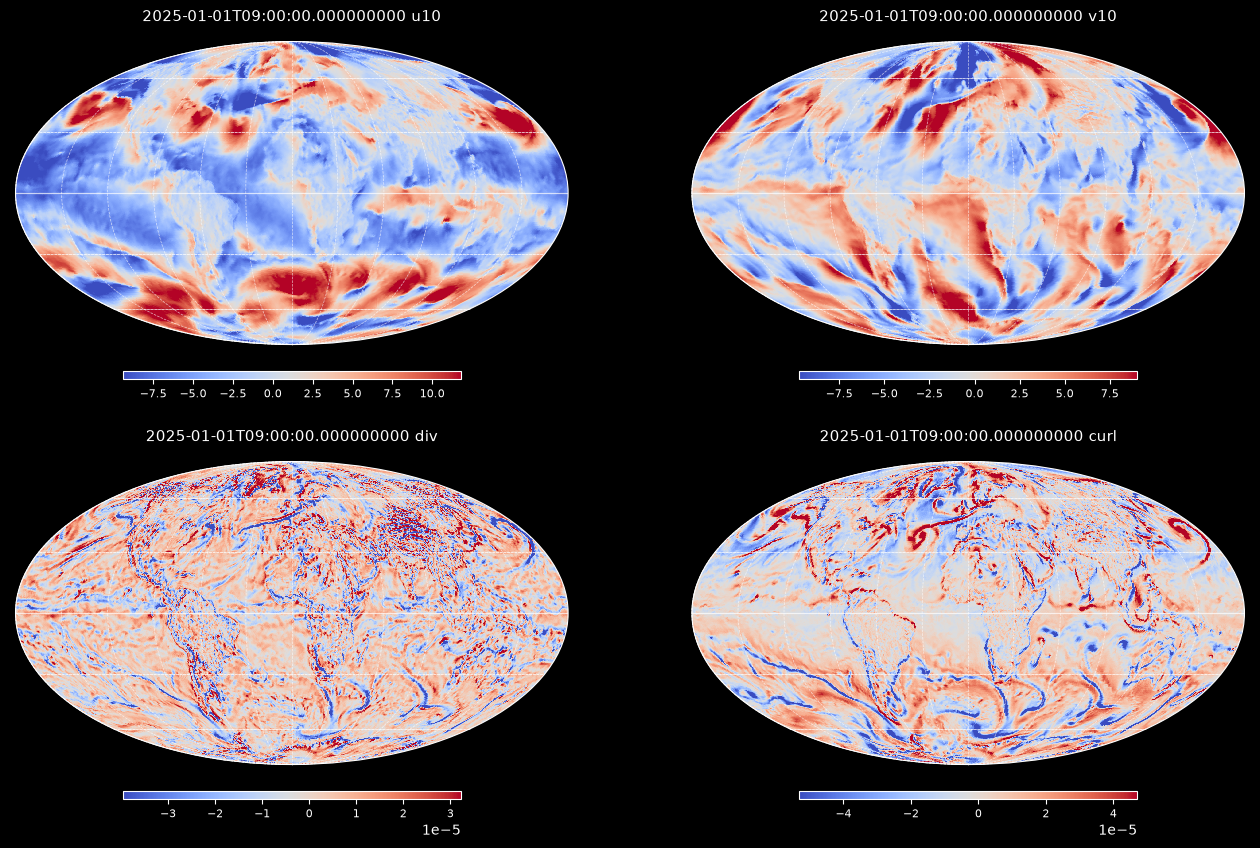

In [9]:
from healpix_plot.mollview import mollview

plt.figure(figsize=(16,10))
mollview(imu.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' u10',hold=False,sub=(2,2,1),nest=True)
mollview(imv.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' v10',hold=False,sub=(2,2,2),nest=True)
mollview(div.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' div',hold=False,sub=(2,2,3),nest=True)
mollview(curl.cpu().numpy(),cmap='coolwarm',title=str(dsG.time.values)+' curl',hold=False,sub=(2,2,4),nest=True)

## Extract the same wind and reference diagnostics on the coastal mask

The global velocity and the global spectral divergence/curl reference are sampled on exactly the same coastal `cell_ids`. Once restricted to this footprint, an ALM derivative of the masked map would no longer be a valid local reference: spherical harmonics are global and the artificial mask couples all modes.

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

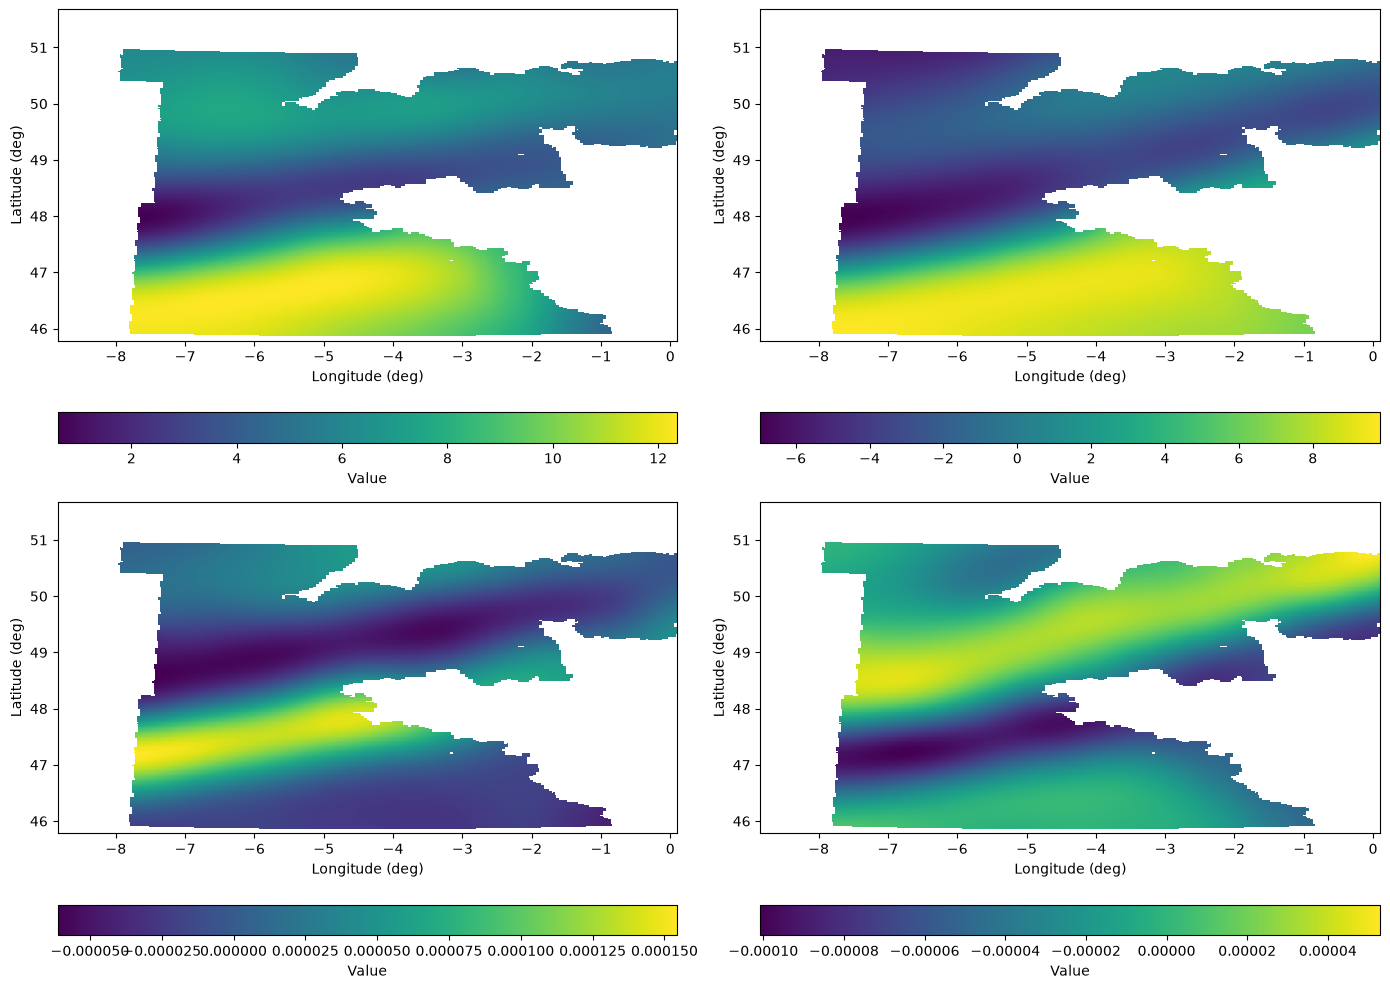

In [10]:
from healpix_analyse import HealPixResampler

resampler = HealPixResampler(
    in_level=ilevel,
    out_level=LEVEL,
    in_cell_ids=None,
    out_cell_ids=cell_ids,
    ellipsoid="sphere",
    dtype=torch.float64,
    device=device,
)

out_u, out_ids = resampler(imu)
out_v, out_ids = resampler(imv)
out_div, out_ids = resampler(div)
out_curl, out_ids = resampler(curl)
cell_ids = out_ids

plt.figure(figsize=(14, 10))
lgnomproject(cell_ids,out_u.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,2,1),interp=True,cbar=True)
lgnomproject(cell_ids,out_v.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,2,2),interp=True,cbar=True)
lgnomproject(cell_ids,out_curl.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,2,3),interp=True,cbar=True)
lgnomproject(cell_ids,out_div.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,2,4),interp=True,cbar=True)

## Single-scale local derivative

This calculation isolates `HealPixDivCurl` before the pyramid is introduced. Its comparison with the spectral reference measures the local derivative stencil and the impact of the coastal mask alone.

In [11]:
layer = HealPixDivCurl(
    level=LEVEL,
    cell_ids=cell_ids,
    kernel_sz=3,
    n_gauges=2,
    gauge_type="phi",
    gauge_reduce="mean",
    ellipsoid="sphere",
    dtype=dtype,
    device=device,
)
velocity=torch.stack([out_u,out_v])

direct_divcurl = layer(velocity)
direct_div = direct_divcurl[0]
direct_curl = direct_divcurl[1]

## Multiscale local divergence and curl

The masked velocity is decomposed into local details plus a coarse map. A distinct `HealPixConv` derivative layer acts on each native grid, so its physical support doubles from one scale to the next. The pyramid stops at the native ALM source level: further Down operations would create a poorly supported coarse diagnostic unrelated to information present in the source wind.

In [12]:
# Do not decompose below the native level of the spectral source.
JMAX = LEVEL - ilevel
decomp = HealPixDecomp(
    level=LEVEL, cell_ids=cell_ids, Jmax=JMAX, ellipsoid="sphere",
    dtype=dtype, device=device,
)
velocity_pyramid = decomp(velocity)
multiscale = HealPixMultiScaleDivCurl(
    decomp,
    kernel_sz=3,
    n_gauges=2,
    gauge_type="phi",
    gauge_reduce="mean"
)
diagnostics = multiscale(velocity_pyramid)

# diagnostics.bands[j] contient [div_j, curl_j] au niveau j
summed_divcurl = decomp.invert(diagnostics.bands)

print(summed_divcurl.shape)
# [2, N] si velocity avait la forme [2, N]

summed_div = summed_divcurl[0]
summed_curl = summed_divcurl[1]

print("levels :", diagnostics.levels)
print("cells  :", [band.shape[-1] for band in diagnostics])
print("spacing:", [f"{value / 1000:.2f} km" for value in diagnostics.pixel_spacing_m])
assert diagnostics.levels == velocity_pyramid.levels
assert len(diagnostics) == len(velocity_pyramid)
for band, ids in zip(diagnostics, diagnostics.cell_ids):
    assert band.shape[-2] == 2
    assert band.shape[-1] == len(ids)
    assert torch.isfinite(band).all()
spacing_ratio = np.asarray(diagnostics.pixel_spacing_m[1:]) / np.asarray(diagnostics.pixel_spacing_m[:-1])
assert np.allclose(spacing_ratio, 2.0)

torch.Size([2, 22781])
levels : (11, 10, 9, 8, 7)
cells  : [22781, 5908, 1570, 448, 135]
spacing: ['3.18 km', '6.37 km', '12.73 km', '25.47 km', '50.93 km']


<Axes: title={'center': 'Spectral physical Curl'}, xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

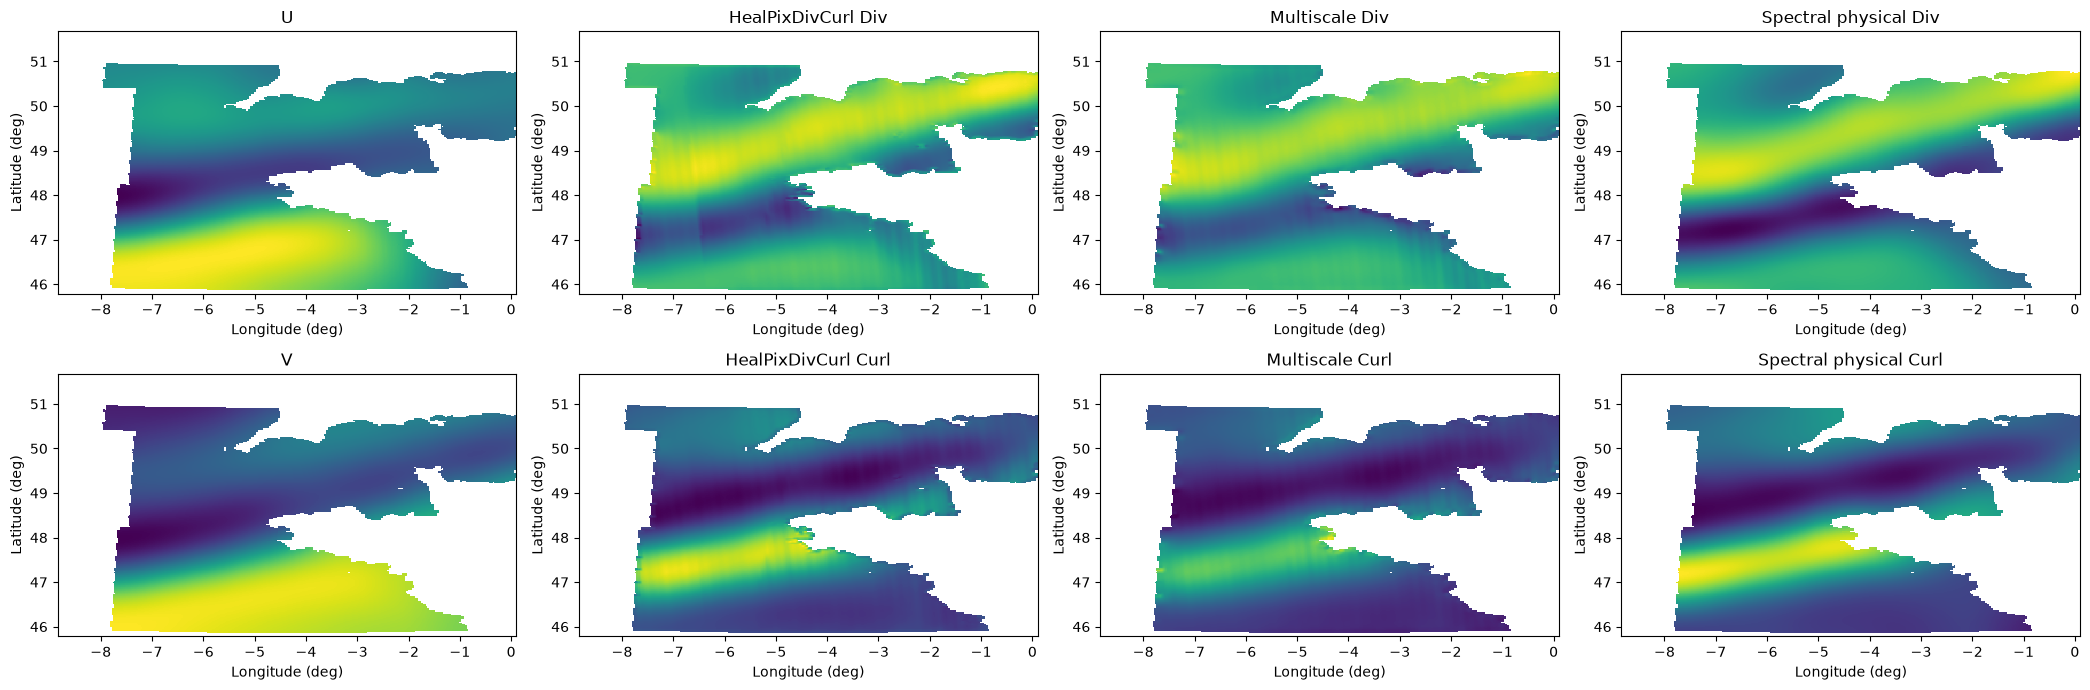

In [13]:
plt.figure(figsize=(21, 7))
lgnomproject(cell_ids,out_u.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,1),interp=True,title='U')
lgnomproject(cell_ids,out_v.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,5),interp=True,title='V')
lgnomproject(cell_ids,direct_div.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,2),interp=True,title='HealPixDivCurl Div')
lgnomproject(cell_ids,direct_curl.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,6),interp=True,title='HealPixDivCurl Curl')
lgnomproject(cell_ids,summed_div.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,3),interp=True,title='Multiscale Div')
lgnomproject(cell_ids,summed_curl.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,7),interp=True,title='Multiscale Curl')
lgnomproject(cell_ids,out_div.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,4),interp=True,title='Spectral physical Div')
lgnomproject(cell_ids,out_curl.cpu().numpy(), 2**LEVEL,hold=False,sub=(2,4,8),interp=True,title='Spectral physical Curl')

## Quantitative comparison

In [14]:
def report_error(name, estimate, reference):
    valid = torch.isfinite(estimate) & torch.isfinite(reference)
    residual_rms = (estimate[valid] - reference[valid]).square().mean().sqrt()
    reference_rms = reference[valid].square().mean().sqrt().clamp_min(1e-30)
    print({
        'case': name,
        'residual_rms_s-1': residual_rms.item(),
        'reference_rms_s-1': reference_rms.item(),
        'relative_rms': (residual_rms / reference_rms).item(),
    })


report_error('single-scale div', direct_div, out_div)
report_error('single-scale curl', direct_curl, out_curl)
report_error('multiscale div', summed_div, out_div)
report_error('multiscale curl', summed_curl, out_curl)

{'case': 'single-scale div', 'residual_rms_s-1': 7.13635771289269e-06, 'reference_rms_s-1': 4.052076009538553e-05, 'relative_rms': 0.17611608706484685}
{'case': 'single-scale curl', 'residual_rms_s-1': 6.414137290871366e-06, 'reference_rms_s-1': 5.230607728250911e-05, 'relative_rms': 0.1226269990813519}
{'case': 'multiscale div', 'residual_rms_s-1': 8.913056257256414e-06, 'reference_rms_s-1': 4.052076009538553e-05, 'relative_rms': 0.21996271136758427}
{'case': 'multiscale curl', 'residual_rms_s-1': 1.1183182493579813e-05, 'reference_rms_s-1': 5.230607728250911e-05, 'relative_rms': 0.2138027371691169}


## Interpretation

All compared diagnostics have physical units of `s^-1`. The ALM result is a global reference computed before masking; the single-scale result isolates the local derivative operator; the multiscale result additionally measures the impact of decomposition and reconstruction.

The coastal mask is deliberately not a physical wind boundary condition. It tests whether a meaningful global signal remains recoverable from an irregular subset, but it cannot validate no-slip/no-flux coastal physics. Cells close to coastlines and the outer mask boundary remain less reliable because their derivative stencil is incomplete. Quantitative scientific validation should therefore also report errors on an eroded interior mask.